In [1]:
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy import optimize

from skimage import io as skio
from skimage.color import rgb2gray, rgb2hed
from skimage.filters import gaussian, median, sobel, frangi, threshold_otsu
from skimage.feature import structure_tensor
from skimage.measure import label, regionprops_table
from skimage.morphology import disk, remove_small_objects
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.transform import resize
from sklearn.decomposition import NMF
from sklearn.neighbors import NearestNeighbors
from pyimzml.ImzMLParser import ImzMLParser, getionimage

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from pathlib import Path
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from skimage import transform, filters
try:
    import SimpleITK as sitk
    SITK_AVAILABLE = True
except ImportError:
    SITK_AVAILABLE = False
    print("WARNING: SimpleITK not installed. B-spline registration unavailable.")
    print("Install with: pip install SimpleITK")
from pyimzml.ImzMLParser import ImzMLParser
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [2]:
FULL_HE_PATH = '/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/D2_10x_originalExport.tif'
IMZML_PATH = '/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML'
MALDI_IMG = '/home/kia/MALDI_Metabolomics/metabol_data/maldi_moving_img.png'

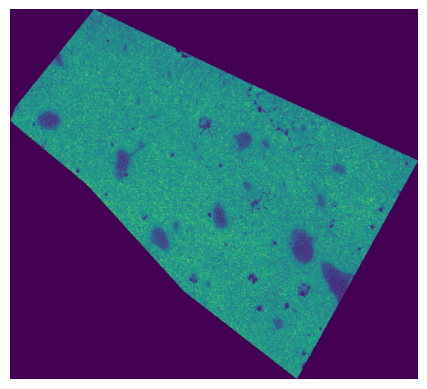

In [3]:
imzml_path = Path(IMZML_PATH)
maldi_parser = ImzMLParser(imzml_path)
ion_mat = getionimage(maldi_parser, 78.958, tol=.0042)

# plot the image w/o borders
def plot_fake_img(img, pic_name, cmap='viridis'):
    plt.figure(frameon=False)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()
plot_fake_img(ion_mat, 'maldi_moving_img')

save the image in the exact dimensions given 

In [4]:
import cv2
cv2.imwrite(MALDI_IMG, (ion_mat / ion_mat.max() * 255).astype(np.uint8))

True

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def pick_landmarks_matplotlib(he_image, maldi_image, n_points):
    print(f"\n{'='*60}\nLANDMARK SELECTION -- click {n_points} vessel pairs\n{'='*60}")
    
    if type(he_image) == sitk.Image:
        print('SimpleITK image format...changing to numpy array')
        he_image = sitk.GetArrayFromImage(he_image)
        maldi_image = sitk.GetArrayFromImage(maldi_image) 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    ax1.imshow(he_image);    ax1.set_title("H&E -- FIRST",   fontweight="bold"); ax1.axis("off")
    ax2.imshow(maldi_image); ax2.set_title("MALDI -- SECOND", fontweight="bold"); ax2.axis("off")

    he_pts, maldi_pts, current = [], [], ["he"]

    def onclick(event):
        if event.inaxes is None:
            return
        x, y = event.xdata, event.ydata

        if event.inaxes == ax1 and current[0] == "he":
            if len(he_pts) < n_points:
                he_pts.append([x, y])
                i = len(he_pts)
                ax1.plot(x, y, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
                ax1.text(x, y, str(i), color="yellow", fontsize=11, fontweight="bold", ha="center", va="center")
                print(f"H&E landmark {i}/{n_points}: ({x:.1f}, {y:.1f})")
            if len(he_pts) == n_points:
                current[0] = "maldi"
                ax2.set_title("MALDI -- CLICK NOW", fontweight="bold", color="red")
                fig.canvas.draw_idle()

        elif event.inaxes == ax2 and current[0] == "maldi":
            if len(maldi_pts) < n_points:
                maldi_pts.append([x, y])
                i = len(maldi_pts)
                ax2.plot(x, y, "ro", markersize=10, markeredgecolor="white", markeredgewidth=2)
                ax2.text(x, y, str(i), color="yellow", fontsize=11, fontweight="bold", ha="center", va="center")
                print(f"MALDI landmark {i}/{n_points}: ({x:.1f}, {y:.1f})")
            if len(maldi_pts) == n_points:
                ax2.set_title("MALDI -- COMPLETE! Close window.", fontweight="bold", color="green")
                fig.canvas.mpl_disconnect(cid)
                fig.canvas.draw()
                plt.close(fig)  # unblocks plt.show(block=True)
                return

        fig.canvas.draw_idle()

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show(block=True)  # blocks here until all landmarks are picked

    print("Landmark selection complete.")
    return np.array(he_pts, dtype=float), np.array(maldi_pts, dtype=float)

In [6]:
def down_sample_sitk(img: sitk, factor: int): 
    # Original size and spacing
    original_size = img.GetSize()
    original_spacing = img.GetSpacing()

    # New size should be as close as possible to the downsample factor
    new_size = [max(1, int(round(s / factor))) for s in original_size]

    # Adjust spacing so physical dimensions stay the same
    new_spacing = [sp * (original_size[i] / new_size[i])
                   for i, sp in enumerate(original_spacing)]

    # Resample
    downsampled = sitk.Resample(
        img,
        new_size,
        sitk.Transform(),
        sitk.sitkLinear,  # use sitkNearestNeighbor for label masks
        img.GetOrigin(),
        new_spacing,
        img.GetDirection(),
        0,
        img.GetPixelID()
)
    return downsampled

In [7]:
# load the images and preprocesses them.

""" SimpleITK landmark registration """
%matplotlib tk
import SimpleITK as sitk

# Build sitk images directly from the arrays — no PNG round-trip
fixed_img = sitk.ReadImage(FULL_HE_PATH, sitk.sitkFloat32)
fixed_img.SetSpacing([1.0, 1.0])
fixed_img.SetOrigin([0.0, 0.0])

moving_image = sitk.ReadImage(MALDI_IMG, sitk.sitkFloat32)
moving_image.SetSpacing([1.0, 1.0])
moving_image.SetOrigin([0.0, 0.0])

# Downsample only the H&E for landmark picking, keep MALDI at native size.
df_factor = 4
fixed_ds = down_sample_sitk(fixed_img, df_factor)

# Picker shows the downsampled H&E and native MALDI image.
fixed_landmarks, moving_landmarks = pick_landmarks_matplotlib(fixed_ds, moving_image, n_points=4)

# Convert picked points into physical coordinates for both images.
fixed_landmarks_phys = np.array([fixed_ds.TransformContinuousIndexToPhysicalPoint(pt)
                                 for pt in fixed_landmarks], dtype=float)
moving_landmarks_phys = np.array([moving_image.TransformContinuousIndexToPhysicalPoint(pt)
                                  for pt in moving_landmarks], dtype=float)

# Fit only rotation + translation — scale is already resolved
landmark_initializer = sitk.LandmarkBasedTransformInitializerFilter()
landmark_initializer.SetFixedLandmarks(fixed_landmarks_phys.flatten().tolist())
landmark_initializer.SetMovingLandmarks(moving_landmarks_phys.flatten().tolist())

#transform = sitk.AffineTransform(2) # Affine shearing is too intense for global registration
transform = sitk.AffineTransform(2)

# use only 3 landmark pairs minimum to fit rotation + translation
output_transform = landmark_initializer.Execute(transform)
print(output_transform)

# Resample moving onto fixed original image space
output_image = sitk.Resample(
    moving_image,
    fixed_img,
    output_transform,
    sitk.sitkLinear,
    0
)


LANDMARK SELECTION -- click 4 vessel pairs
SimpleITK image format...changing to numpy array
H&E landmark 1/4: (1893.1, 1076.0)
H&E landmark 2/4: (2195.5, 1634.2)
H&E landmark 3/4: (2820.2, 1727.7)
H&E landmark 4/4: (2662.8, 1267.8)
MALDI landmark 1/4: (95.7, 104.5)
MALDI landmark 2/4: (272.3, 442.5)
MALDI landmark 3/4: (652.9, 512.9)
MALDI landmark 4/4: (565.3, 225.9)
Landmark selection complete.
itk::simple::AffineTransform
 AffineTransform (0x636d58bbf4d0)
   RTTI typeinfo:   itk::AffineTransform<double, 2u>
   Reference Count: 1
   Modified Time: 2091
   Debug: Off
   Object Name: 
   Observers: 
     none
   Matrix: 
     0.153358 -0.00436875 
     0.00317383 0.151859 
   Offset: [-1046.49, -575.391]
   Center: [0, 0]
   Translation: [-1046.49, -575.391]
   Inverse: 
     6.51682 0.187479 
     -0.1362 6.58113 
   Singular: 0



checking to see if the initial alignment gives us a reasonable coordinate structure 

# Fine Scale Alignment

In [8]:
# Build a ones-image with the same geometry as the MALDI
ones_arr = np.ones(sitk.GetArrayFromImage(moving_image).shape[:2], dtype=np.float32)
maldi_ones = sitk.GetImageFromArray(ones_arr)
maldi_ones.CopyInformation(moving_image)

# Warp it: 1 where MALDI exists, exactly 0 elsewhere
coverage = sitk.Resample(maldi_ones, fixed_img, output_transform,
                         sitk.sitkNearestNeighbor, 0.0)
mask = sitk.GetArrayFromImage(coverage) > 0.5

ys, xs = np.where(mask)
y_min, y_max = int(ys.min()), int(ys.max()) + 1
x_min, x_max = int(xs.min()), int(xs.max()) + 1

he_img = skio.imread(FULL_HE_PATH)
cropped_img = he_img[y_min:y_max, x_min:x_max]
# save the cropped image 
skio.imsave(fname='/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif', arr=cropped_img)
#plt.imshow(cropped_img)

getting the cropped image into the original coordinates

In [9]:
he_img = skio.imread(FULL_HE_PATH)
cropped_img = skio.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif')

# blank canvas matching the full H&E
reconstructed = np.zeros_like(he_img)

# place the crop back at its original position
reconstructed[y_min:y_max, x_min:x_max] = cropped_img

In [10]:
plt.imshow(he_img)
plt.imshow(reconstructed, alpha=0.5)

Got the initial transform done with the correct cropped region 

### Sinusoid Mask

In [11]:
from pathlib import Path
# grey scale normalization
IMAGE_PATH = Path('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif') 
bgr  = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

In [12]:

def dbscan_1d_ish(imzml_path: str, mz_tol: float, min_intensity: float, min_count: int) -> pd.DataFrame:
    """
    Perform DBSCAN-like clustering on the m/z values in the dataframe. Clusters for now
    will be defined as contiguous regions where the difference between adjacent m/z values is less than mz_tol.
    Clusters with fewer than min_count points will be flagged as "noise".

    :param mz_tol: the tolerance for the m/z values
    :param min_intensity: the minimum intensity for a m/z to be considered
    :param min_count: the minimum number of points to form a cluster

    :return: a DataFrame with additional columns for delta_mz, in_dense_region, and cluster_labels
    :rtype: pandas.DataFrame
    """
    parser = ImzMLParser(imzml_path)
    df =pd.DataFrame(
                (   # neat trick to unpack the mzs and intensities directly into the row
                    # * is a unpacking operator called splat and it unpacks the tuple of mzs and intensities
                    # from getspectrum into individual elements in the new tuple
                    (*parser.getspectrum(idx), (x,y)) for idx, (x,y,_) in enumerate(parser.coordinates)
                ),
                    columns=["mzs", "intensities", "coordinates"]
        )
    # pull raw arrays out of the dataframe — no copies yet
    mzs_arr    = df['mzs'].to_numpy()
    intens_arr = df['intensities'].to_numpy()
    coords_arr = df['coordinates'].to_numpy()

    # single-pass concatenation — much faster than explode
    all_mzs    = np.concatenate(mzs_arr).astype(np.float32)
    all_intens = np.concatenate(intens_arr).astype(np.float32)
    lengths    = np.fromiter((len(a) for a in mzs_arr), dtype=np.int32, count=len(mzs_arr))
    all_coords = np.repeat(coords_arr, lengths)

    # filter BEFORE building the dataframe — avoids allocating rows you'll discard
    mask       = all_intens > min_intensity
    all_mzs    = all_mzs[mask]
    all_intens = all_intens[mask]
    all_coords = all_coords[mask]

    # sort on numpy arrays — faster than df.sort_values + reset_index
    print(f"Sorting m/z values...{mask.sum()} values")
    order      = np.argsort(all_mzs, kind='stable')

    print(f"building long_df")
    long_df = pd.DataFrame({
        'mzs':         all_mzs[order],
        'intensities': all_intens[order],
        'coordinates': all_coords[order],
    })

    
    print(f'\nlong_df columns: {long_df.columns}\n')  # print the columns of long_df.columns)
    
    # check if long
    # find the deltas between adjacent m/z values
    print("calculating deltas")
    delta_values = -1 * long_df['mzs'].values[0:(len(long_df) - min_count)] + long_df['mzs'].values[min_count:(len(long_df) + min_count)]
    
    # 0 padding missing values to match the length of the dataframe
    long_df['delta_mz'] = np.concatenate([delta_values, [0] * min_count])
    del delta_values

    # creating a boolean mask for regions where delta_mz < mz_tol
    long_df['in_dense_region'] = (long_df['delta_mz'] < mz_tol).astype(int)

    # Calculating difference of boolean flags
    # Calculate diff without fillna to get proper length n-1
    difference = np.diff(long_df['in_dense_region'].values)
    difference_plus = np.maximum(difference, 0)
    running_clusternr = np.cumsum(difference_plus)
    del difference
    del difference_plus

    # intermediate vector of of boolean flags
    delta = long_df['in_dense_region'].values

    # Now both have compatible shapes: delta[:-1] and running_clusternr are both length n-1
    clusternr = delta[:-1] * running_clusternr
    del running_clusternr

    # 0 padding missing values to match the length of the dataframe
    long_df['cluster_labels'] = np.concatenate([[delta[0]], clusternr])
    del clusternr
    del delta

    # Remove noise clusters
    # going to prune the data
    long_df = long_df[long_df["cluster_labels"] != 0]

    # Remove clusters with fewer than N mz values
    long_df = long_df[long_df.groupby('cluster_labels') ['mzs'].transform('size') >= min_count]

    import scipy.sparse as sp

    # grouping mzs based on the median of the cluster labels, and summing the intensities for each coordinate and mz_label pair
    print("Grouping m/z values and summing intensities...")
    grouped = (
        long_df
        .assign(mz_label=long_df.groupby('cluster_labels')['mzs'].transform('median'))
        .groupby(['coordinates', 'mz_label'])['intensities']
        .sum()
    )

    # Build integer codes for rows (coordinates) and cols (mz_label)
    print("Getting the coordinate and mz labels")
    coord_idx, coord_labels = pd.factorize(grouped.index.get_level_values('coordinates'))
    mz_idx,    mz_labels    = pd.factorize(grouped.index.get_level_values('mz_label'))
    
    # making it sparse to save memory
    print("Generating spot x feature matrix (sparse)...")
    spot_feature_matrix = sp.csr_matrix(
        (grouped.values, (coord_idx, mz_idx)),
        shape=(len(coord_labels), len(mz_labels))
    )


    return spot_feature_matrix, coord_labels, mz_labels


In [13]:
imzml_path = "/home/kia/MALDI_Metabolomics/metabol_data/20251012_old_liver.imzML"

In [14]:
spot_feature_matrix, coord_labels, mz_labels = dbscan_1d_ish(imzml_path, mz_tol=0.0042, min_intensity=5, min_count=25)

Sorting m/z values...39694844 values
building long_df

long_df columns: Index(['mzs', 'intensities', 'coordinates'], dtype='object')

calculating deltas
Grouping m/z values and summing intensities...
Getting the coordinate and mz labels
Generating spot x feature matrix (sparse)...


In [50]:
from skimage import color, morphology
from skimage.segmentation import clear_border

def compute_sinusoid_mask_from_he(he_img,
                                  max_size=10000,
                                  min_size=100,
                                  otsu_bias=1.0):
    # grayscale brightness
    gray = color.rgb2gray(he_img)               # (H, W), range [0, 1]

    # min(R,G,B) — high only when all channels are high (truly white)
    rgb_min = he_img.min(axis=-1)               # (H, W), range [0, 1]

    # combine: a pixel must be bright in both — filters pink (bright gray, low blue)
    white_signal = np.minimum(gray, rgb_min)    # (H, W)

    thr = threshold_otsu(white_signal) * otsu_bias
    interior = clear_border(white_signal > thr)

    large_enough = morphology.remove_small_objects(interior, max_size=min_size - 1)
    too_large    = morphology.remove_small_objects(interior, max_size=max_size - 1)
    return (large_enough ^ too_large).astype(np.float32)



In [16]:
# getting the map from MALDI to H&E coordinates using the inverse of the output_transform
inv_transform = output_transform.GetInverse()

# getting the coordinates of the MALDI pixels in the H&E space using the inverse transform
parser = ImzMLParser(imzml_path)
maldi_coords = [[x, y] for x, y, _ in parser.coordinates]

# apply to all MALDI coordinates at once
T0_maldi_coords = np.array([inv_transform.TransformPoint((float(x), float(y)))
                       for x, y in maldi_coords])
T0_maldi_coords

array([[ 7990.11516001,  3628.57216729],
       [ 7996.63198328,  3628.43596681],
       [ 7990.30263874,  3635.1532953 ],
       ...,
       [10664.97361608,  8254.63600038],
       [10671.49043936,  8254.4997999 ],
       [10671.67791809,  8261.08092792]], shape=(269511, 2))

In [17]:
import matplotlib.image as mpimg

ion_mat = getionimage(parser, 78.958, tol=0.0042)
png_img = mpimg.imread(MALDI_IMG)

print("Raw MALDI grid shape:", ion_mat.shape)   # (Hm, Wm) — actual grid
print("PNG shape used in reg:", png_img.shape)   # (H, W) — what transform knows about


Raw MALDI grid shape: (713, 787)
PNG shape used in reg: (713, 787)


In [18]:
import skimage

# then we get our sinusoid mask from the H&E image called S_HE in the manuscript
cropped_img = skimage.io.imread('/home/kia/MALDI_Metabolomics/metabol_data/high_res_MSI/he_cropped.tif')

In [51]:
# correct — Otsu sees only real tissue pixels
S_HE = compute_sinusoid_mask_from_he(cropped_img)

# if you need it back in full H&E coordinates afterward:
S_HE_full = np.zeros(he_img.shape[:2], dtype=np.float32)
S_HE_full[y_min:y_max, x_min:x_max] = S_HE

plt.imshow(S_HE_full)
plt.title("Sinusoid mask from H&E")
plt.show()

In [20]:
from sklearn.neighbors import NearestNeighbors

# get the nearest neighbors of the T0_maldi_coords and the distance between these points 
neigh = NearestNeighbors(n_neighbors=2)
neigh.fit(T0_maldi_coords)
distances, _ = neigh.kneighbors(T0_maldi_coords)
r = np.median(distances[:, 1])
h = 1.5*r

In [21]:
r

np.float64(6.518246404065359)

In [22]:
import numpy as np
from scipy.signal import convolve2d


def _create_wendland_kernel(h):
    """
    Create normalized Wendland C2 kernel.

    h = kernel support parameter
    """

    radius = int(np.ceil(np.sqrt(h)))

    x = np.arange(-radius, radius+1) # x length of kernel (2*radius+1)
    y = np.arange(-radius, radius+1) # y length (same as x)

    X, Y = np.meshgrid(x, y) # building the kernel grid 

    r2 = X**2 + Y**2 # radial area of influence

    kernel = np.zeros_like(r2, dtype=float) # making the kernel with the same shape as r2 but filled with zeros

    inside = r2 < h # boolean mask for the points that are within the cutoff radius h

    kernel[inside] = (
        (1 - r2[inside]/h)**4 *
        (4*r2[inside]/h + 1)
    ) # function for Wendland C2 kernel (determines influence of each pixel based on distance from center)

    # normalize C_h
    kernel /= kernel.sum()

    return kernel



def smooth_HE_mask(S_HE, h):
    """
    Wendland smoothing of binary H&E mask.

    S_HE:
        binary numpy array

    h:
        kernel support parameter
    """

    K_h = _create_wendland_kernel(h)

    S_HE_tilde = convolve2d(
        S_HE,
        K_h,
        mode="same",
        boundary="symm"
    )

    return S_HE_tilde

#S_HE_tilde = smooth_HE_mask(S_HE_full, h)
#plt.imshow(S_HE_tilde)
#plt.title("Smoothed sinusoid mask from H&E")
#plt.show()

In [23]:
from scipy.ndimage import map_coordinates
def project_to_msi(S_smooth, T_U):
    """
    S_smooth: smoothed H&E image
    T_U: (N,2) transformed MSI coordinates in H&E space
    """

    # scipy uses (row, col) = (y, x)
    coords = np.vstack([T_U[:,1], T_U[:,0]])

    values = map_coordinates(
        S_smooth,
        coords,
        order=1,      # bilinear interpolation
        mode='nearest'
    )

    return values


In [52]:
h = 1.5 * r
print("smooth the mask")
S_smooth = smooth_HE_mask(S_HE_full, h)
print("project the smoothed mask to the MALDI space")
S_t = project_to_msi(S_smooth, T0_maldi_coords)

smooth the mask
project the smoothed mask to the MALDI space


In [40]:
np.unique(S_t, return_counts=True)

(array([0.00000000e+00, 1.86752336e-08, 2.31960285e-08, ...,
        9.99999988e-01, 1.00000000e+00, 1.00000000e+00], shape=(7000,)),
 array([260073,      1,      1, ...,      1,     37,   2404], shape=(7000,)))

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    T0_maldi_coords[:,0],          # x coordinates
    T0_maldi_coords[:,1],          # y coordinates
    c=S_t,             # color = projected value
    s=4,               # marker size
    cmap="viridis"
)

plt.gca().invert_yaxis()   # optional, matches image coordinates
plt.colorbar(label="S_t")
plt.title("Projected H&E mask on MSI coordinates")
plt.xlabel("H&E x")
plt.ylabel("H&E y")

plt.show()

In [53]:
he_img = skio.imread(FULL_HE_PATH)
plt.figure(figsize=(10,10))

plt.imshow(he_img)

plt.scatter(
    T0_maldi_coords[:,0],
    T0_maldi_coords[:,1],
    c=S_t,
    s=6,
    cmap="jet"
)

plt.colorbar(label="Projected value")
plt.title("Projected MSI values over H&E")

plt.show()

Now we will attempt to do a ridge regression and calculate pearson correlation based off of the coefficients
of the linear regression

Implenting without complete ridge regression because the data unfortunatey is not centered (so ridge regression + workarounds)

In [54]:
# center and scaling in two different ways
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

# Standardize X
X = spot_feature_matrix.toarray().astype(np.float32)  # convert sparse matrix to dense
X_scaled = StandardScaler().fit_transform(X)

# Standardize target
s_scaled = StandardScaler().fit_transform(
    S_t.reshape(-1,1)
).ravel()

ridge = Ridge(
    alpha=0.01,
    fit_intercept=False
)

ridge.fit(X_scaled, s_scaled)

w_hat = ridge.coef_

# Normalize to unit norm
w_hat /= np.linalg.norm(w_hat)

# Metafeature
x_hat = X_scaled @ w_hat

# correlation time 
corr, p = pearsonr(x_hat, s_scaled)

print(corr)

0.062076242716252644


This is because it is 

In [55]:
import matplotlib.pyplot as plt

# --- top contributing m/z channels by absolute weight ---
mz_cols = mz_labels # the median m/z labels
top_n = 4
top_idx = np.argsort(np.abs(w_hat))[::-1][:top_n]

print("Top m/z channels by |weight|:")
for rank, i in enumerate(top_idx):
    print(f"  {rank+1}. m/z={mz_cols[i]:.4f}  w={w_hat[i]:+.4f}")

# --- scatter plot: metafeature x_hat vs sinusoid target s ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter: each point is one MALDI spot
axes[0].scatter(x_hat, s_scaled, s=1, alpha=0.3, c='steelblue')
axes[0].set_xlabel("metafeature  $\\hat{x} = X\\hat{w}$")
axes[0].set_ylabel("sinusoid target  $s$")
axes[0].set_title(f"Pearson r = {corr:.4f}")

# bar chart of top weights — helps see which m/z drives the metafeature
axes[1].barh(
    [f"{mz_cols[i]:.3f}" for i in top_idx[::-1]],
    w_hat[top_idx[::-1]],
    color=["tomato" if w > 0 else "steelblue" for w in w_hat[top_idx[::-1]]]
)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_xlabel("weight $\\hat{w}$")
axes[1].set_title(f"Top {top_n} m/z by |weight|")

plt.tight_layout()
plt.show()


Top m/z channels by |weight|:
  1. m/z=190.8662  w=-0.3945
  2. m/z=75.9616  w=+0.1918
  3. m/z=124.0070  w=-0.1695
  4. m/z=193.0777  w=+0.1557


In [ ]:
ion_mat = getionimage(maldi_parser, 190.8662, tol=.0042)
plt.imshow(ion_mat, cmap='viridis')